# Laboratory 2

Tridiagnonal matrix algorithm (TMDA) or the Thomas Algorithm is an efficient way to solve systems of equations whose coefficient matrix is tridiagonal.  This approach comes in handy when solving $2^{nd}$ Order ODEs (Boundary Value Problems) as well as 1D parabolic partial differential equations such those depicting the flow of heat, mass and momentum in natural and engineered systems.  Understanding this algorithm is therefore beneficial to engineers.

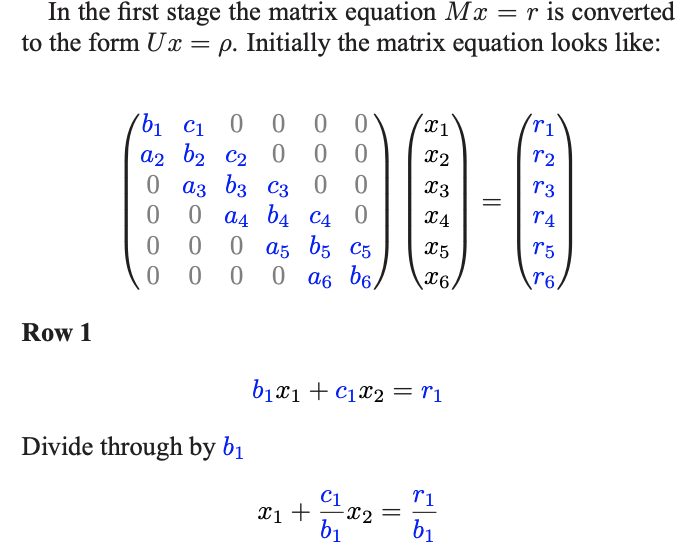

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

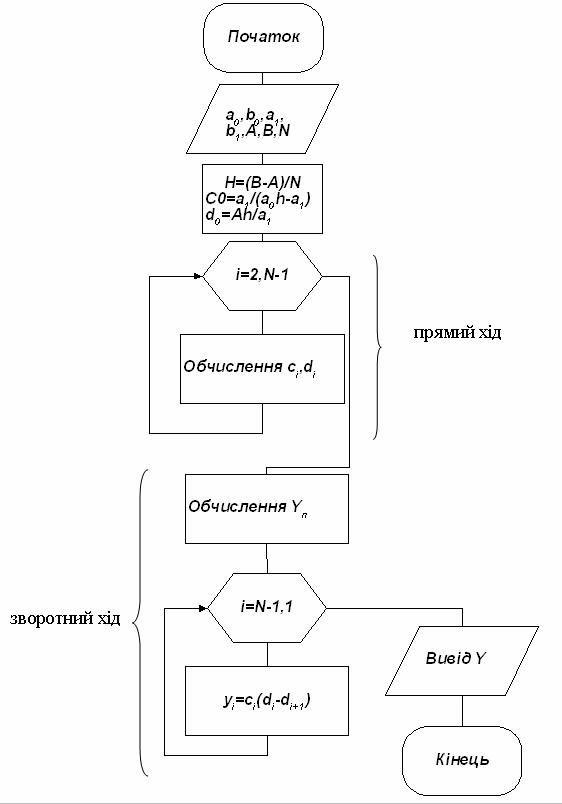

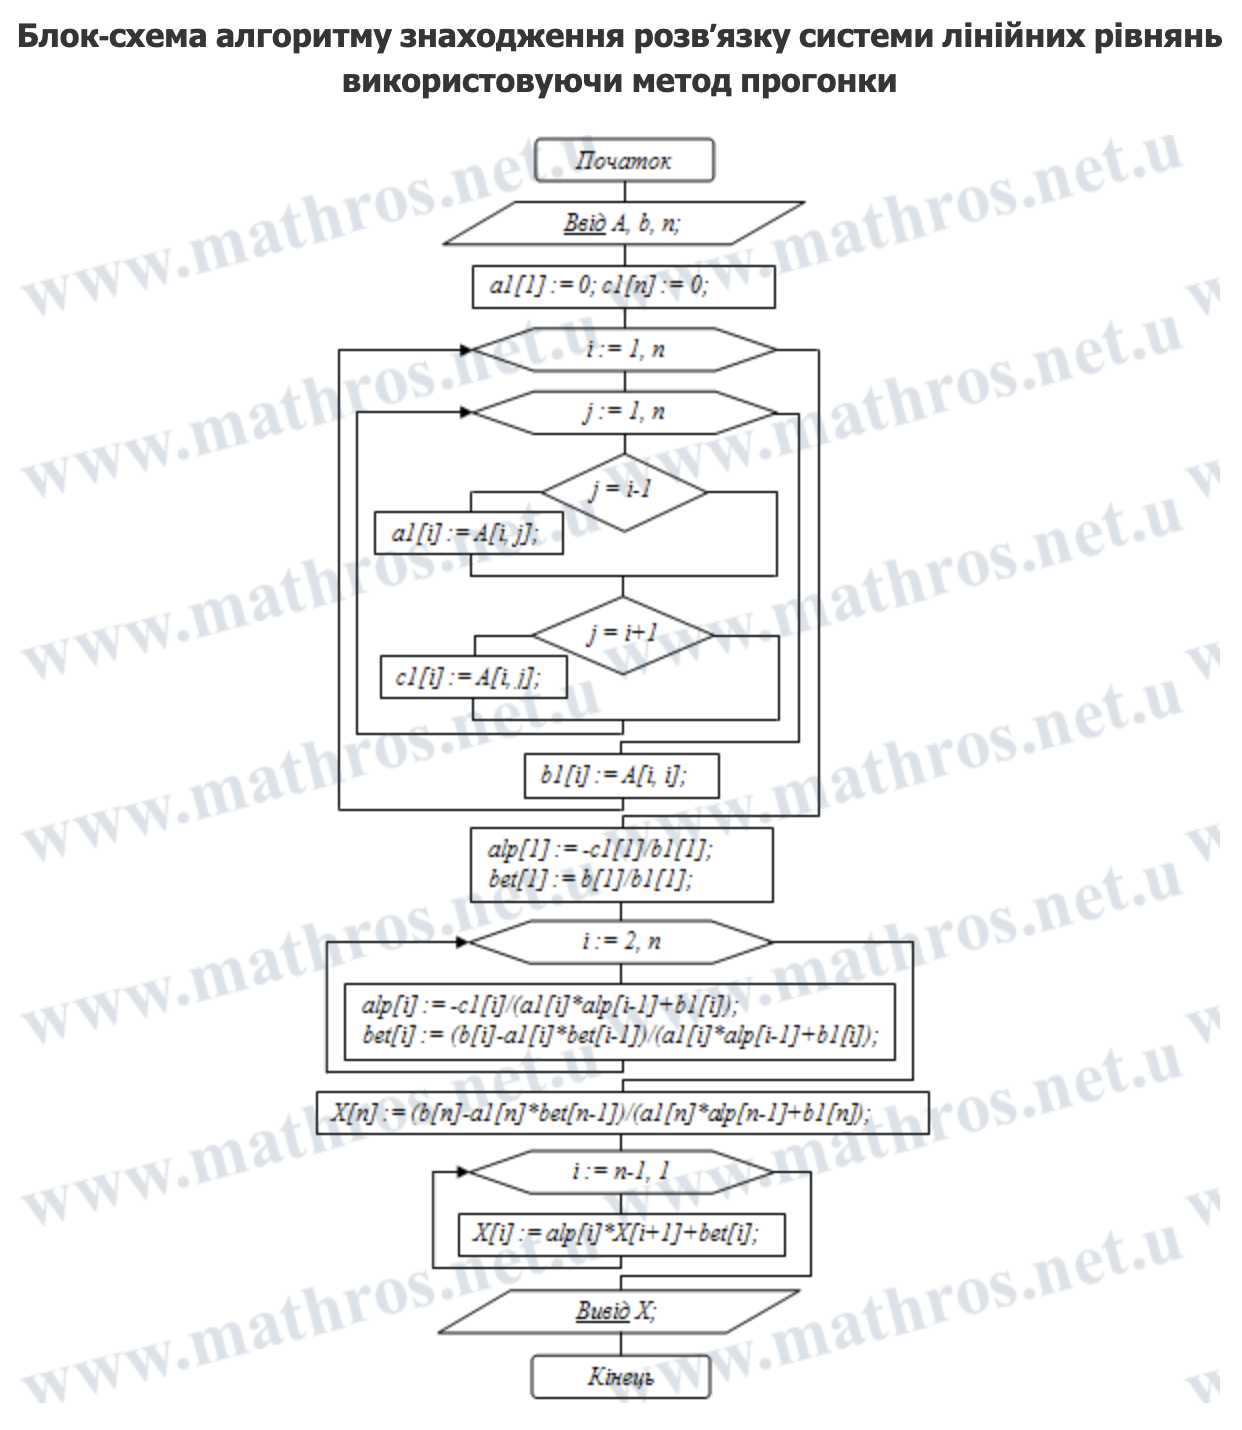


$$ y''(x_i) \approx \frac{y_{i-1} - 2y_i + y_{i+1}}{h^2} $$


$$
y'(x_i) \approx \frac{y_{i+1} - y_{i-1}}{2h}
$$


$$
\frac{y_{i-1} - 2y_i + y_{i+1}}{h^2} + p(x_i) \cdot \frac{y_{i+1} - y_{i-1}}{2h} + q(x_i) y_i = f(x_i)
$$



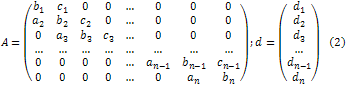

 прямої прогонки полягає в тому, що кожне невідоме  виражається за допомогою прогоночних коефіцієнтів x і 

In [117]:
def thomas(A, b):
    n = len(b)
    a1 = np.zeros(n)
    b1 = np.zeros(n)
    c1 = np.zeros(n)

    a1[0] = 0
    c1[-1] = 0

    for i in range(n):
        for j in range(n):
            if j == i - 1:
                a1[i] = A[i][j]
            elif j == i + 1:
                c1[i] = A[i][j]
            elif j == i:
                b1[i] = A[i][j]

    alp = np.zeros(n)
    bet = np.zeros(n)

    alp[0] = -c1[0] / b1[0]
    bet[0] = b[0] / b1[0]

    for i in range(1, n):
        alp[i] = -c1[i] / (a1[i] * alp[i - 1] + b1[i])
        bet[i] = (b[i] - a1[i] * bet[i - 1]) / (a1[i] * alp[i - 1] + b1[i])

    X = np.zeros(n)
    X[-1] = bet[-1]

    for i in range(n - 2, -1, -1):
        X[i] = alp[i] * X[i + 1] + bet[i]

    return X

$$\frac{d^2 y}{dx^2} + p(x) \frac{dy}{dx} + q(x) y = f(x)$$

$$\left(1 - \frac{x}{2} h\right) y_{i-1} + \left(-2 + h^2\right) y_i + \left(1 + \frac{x}{2} h\right) y_{i+1} = h^2 \sin(x_i)$$

$h = \frac{x_{max} - x_{min}}{N} = \frac{1 - 0}{50} = 0.02$.

In [118]:
def direchle():
    N = 50
    h = 1.0 / N
    x = np.linspace(0, 1, N + 1)

    y0 = 1.0  
    yN = 0.0  

    n = N - 1
    a = np.zeros(n)  
    b = np.zeros(n)  
    c = np.zeros(n)  
    d = np.zeros(n)  

    for i in range(1, N):
        x_i = x[i]
        y_imin1 = 1 - (x_i * h) / 2
        B_y_i = -2 + h ** 2
        C_y_plus_i = 1 + (x_i * h) / 2
        D_i = h ** 2 * np.sin(x_i)
        idx = i - 1
        a[idx] = y_imin1
        b[idx] = B_y_i
        c[idx] = C_y_plus_i
        d[idx] = D_i

    d[0] = d[0] - a[0] * y0
    a[0] = 0.0

    d[-1] = d[-1] - c[-1] * yN
    c[-1] = 0.0


    A = np.zeros((n, n))
    for i in range(n):
        if i > 0:
            A[i][i - 1] = a[i]
        A[i][i] = b[i]
        if i < n - 1:
            A[i][i + 1] = c[i]


    tomas_x = thomas(A, d)

    y = np.zeros(N + 1)
    y[0] = y0
    y[1:N] = tomas_x
    y[N] = yN

    return x, y

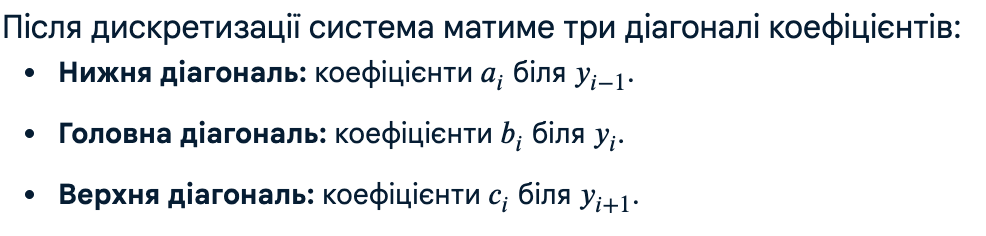

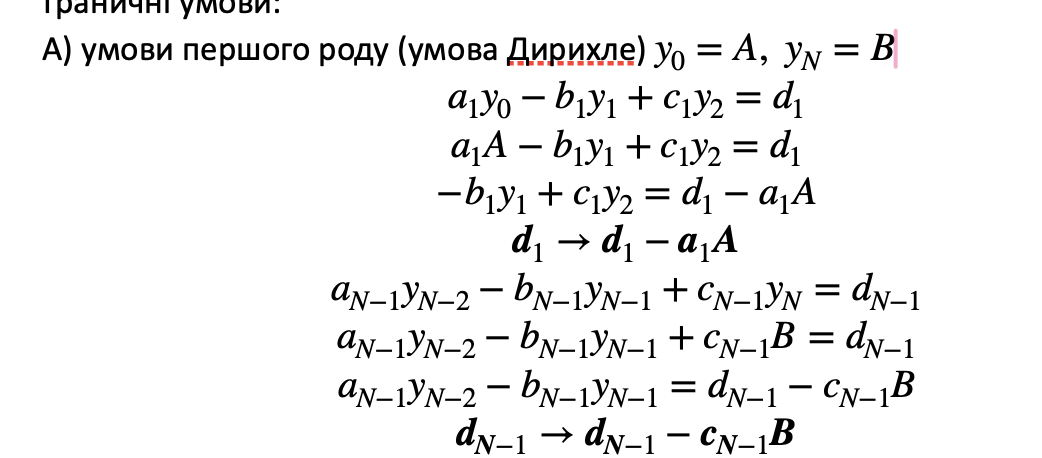

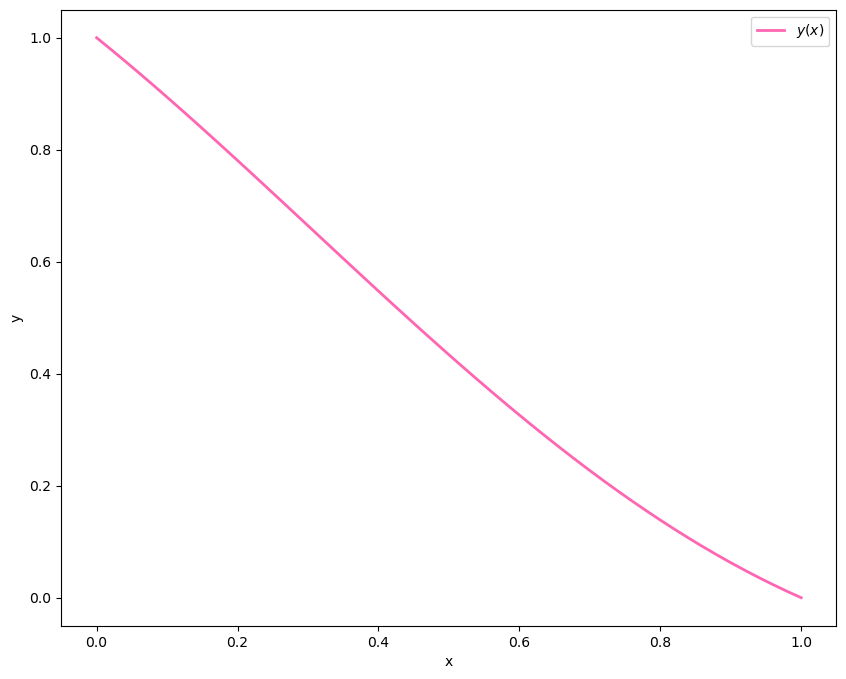

In [121]:
x, y = direchle()

plt.figure(figsize=(10, 8))
plt.plot(x, y, color="#ff66b2", linewidth=2, label='$y(x)$')
plt.xlabel('x', fontsize=10)
plt.ylabel('y', fontsize=10)
plt.legend()
plt.show()

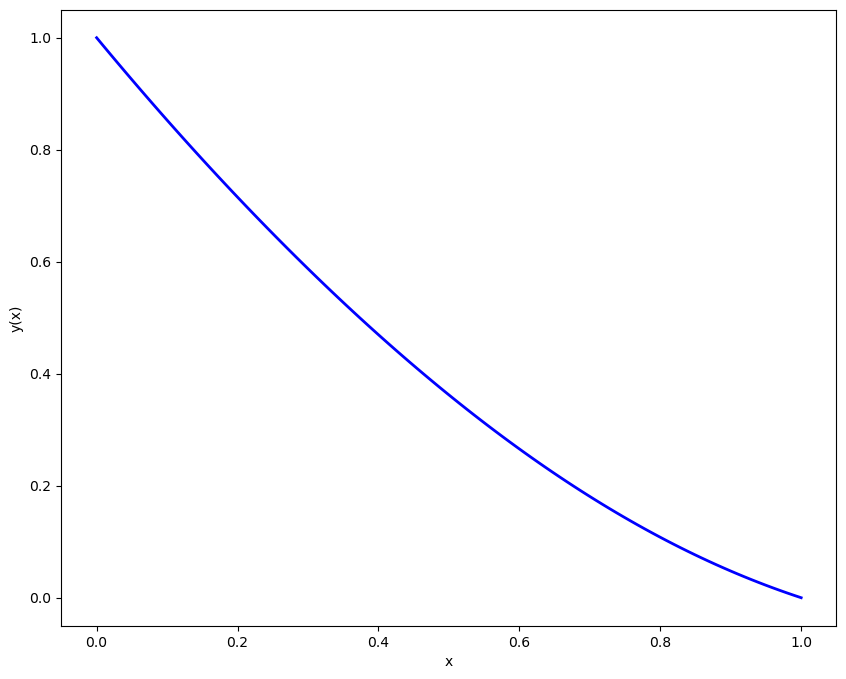

In [120]:
x = np.linspace(0, 1, 100)
y_guess = np.array([1 - x, -np.ones_like(x)])
sol = solve_bvp(lambda x,y: np.vstack((y[1], np.sin(x)-x**2*y[1]+y[0])), 
                lambda ya,yb: [ya[0]-1, yb[0]], x, y_guess)

plt.figure(figsize=(10, 8))
plt.plot(sol.x, sol.y[0], 'b-', linewidth=2, markersize=4)
plt.xlabel('x')
plt.ylabel('y(x)')
plt.show()
